In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

L = 100 #number of lattice points in each dimension
size = L #total number of lattice points
J = 1  #Coupling Coefficient
N = 1000 #number of monte-carlo steps
Nt = 20 #number of temperatures sampled
Temps = np.logspace(-2,3,Nt)

#Data Collection
M_t = np.zeros(N) #magnetization
E_t = np.zeros(N) #energy per spin/lattice point
s_T = []
M_T = np.zeros(Nt)
E_T = np.zeros(Nt)

#Iterate over Temps
Tcounter = 0
for T in Temps:
    #Begin in Random Initial State
    state = np.random.choice([-1,1],L)
    state_i = state.copy()
    #Begin Iteration of MCS (monte-carlo steps)
    for n_out in range(N):
        #compute and store magnetization
        M_t[n_out] = np.sum(state)/size
        #compute and store energy per spin
        E_t[n_out] = -J*np.sum(state*np.roll(state,1))/size
        #For each MCS, attempt flipping one spin for every lattice point
        for n_in in range(size):
            #choose a random lattice point
            xpos = np.random.randint(0,L)
            xp = xpos+1
            if xp == L:
                xp = 0
            xm = xpos-1
            #calculate change in energy of prospective flip
            dU = 2*J*state[xpos]*(state[xm] + state[xp])
            #decide whether to flip
            if dU <= 0:
                state[xpos] *= -1
            elif np.random.rand() < np.exp(-dU/T):
                state[xpos] *= -1
    M_T[Tcounter] = np.sum(M_t)/N
    E_T[Tcounter] = np.sum(E_t)/N
    state_f = state.copy()
    s_T.append((state_i,state_f))
    Tcounter += 1


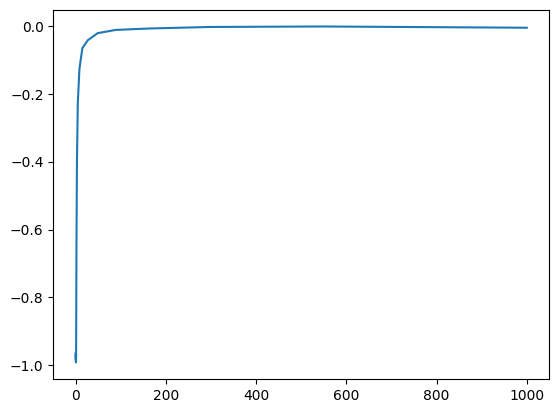

In [27]:
#Plot <E>(T)
plt.plot(Temps,E_T)
plt.show()

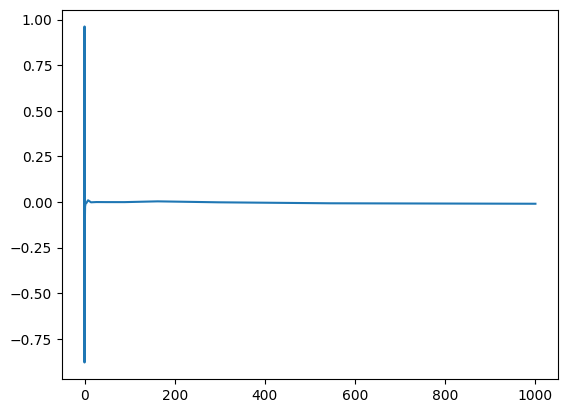

In [28]:
#Plot <M>(T)
plt.plot(Temps,M_T)
plt.show()

In [39]:
for i_T in range(Nt):
    print(f'Temperature: {Temps[i_T]}')
    plt.imshow(np.array([s_T[i_T][0]]))
    plt.xticks([]);
    plt.yticks([]);
    plt.show()
    plt.imshow(np.array([s_T[i_T][1]]))
    plt.xticks([]);
    plt.yticks([]);
    plt.show()

Temperature: 0.01


Temperature: 0.018329807108324356


Temperature: 0.03359818286283781


Temperature: 0.06158482110660264


Temperature: 0.11288378916846889


...

Temperature: 88.58667904100822


Temperature: 162.3776739188721


Temperature: 297.63514416313194


Temperature: 545.5594781168514


Temperature: 1000.0
